In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = data.data
y = data.target

# Convert to DataFrame for better viewing
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
print(data.target_names)

['malignant' 'benign']


In [3]:
print(df.shape)

(569, 31)


In [4]:
df['target'].value_counts()

,count
target,
1,357
0,212


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve

In [8]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

GaussianNB()

In [11]:
y_pred = nb_model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Naive Bayes Model:", accuracy)

Accuracy of Naive Bayes Model: 0.9370629370629371


In [13]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of Naive Bayes Model:", accuracy)

Accuracy of Naive Bayes Model: 0.9370629370629371


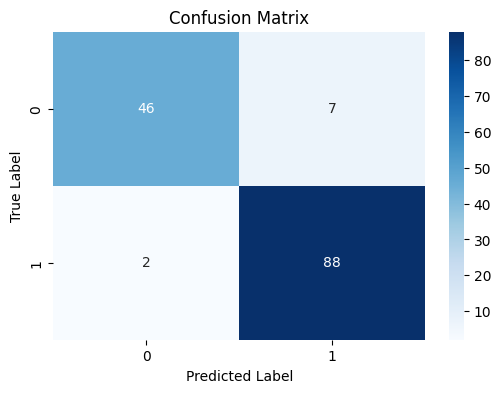

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [15]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.87      0.91        53
           1       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143



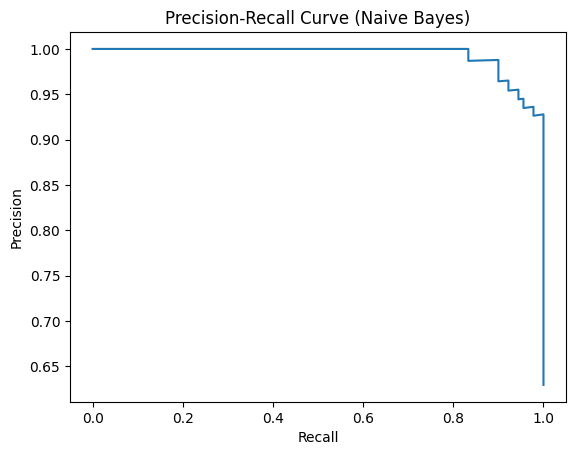

In [16]:
y_scores = nb_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Naive Bayes)")
plt.show()

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve

In [18]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
y_pred_dt = dt_model.predict(X_test)

In [20]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.9230769230769231


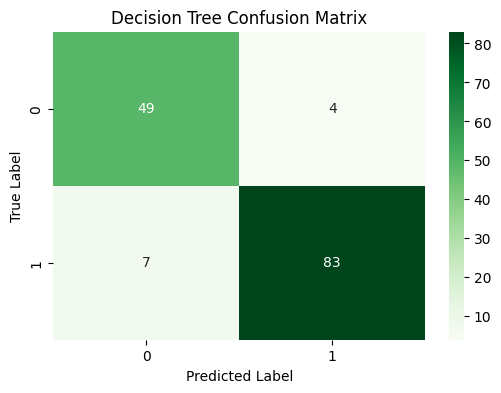

In [21]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [22]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred_dt))

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.92      0.90        53
           1       0.95      0.92      0.94        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143



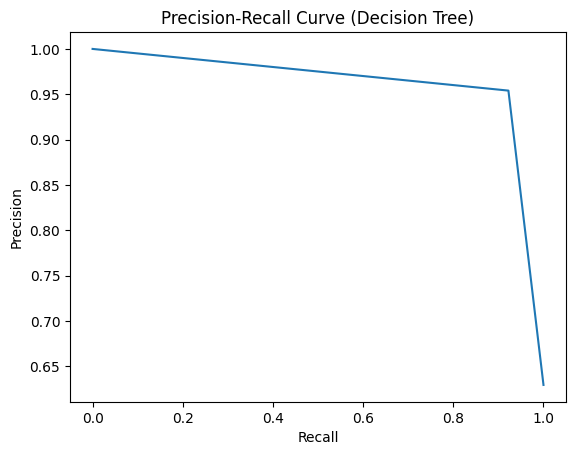

In [23]:
y_scores_dt = dt_model.predict_proba(X_test)[:,1]

precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_scores_dt)

plt.plot(recall_dt, precision_dt)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Decision Tree)")

plt.show()

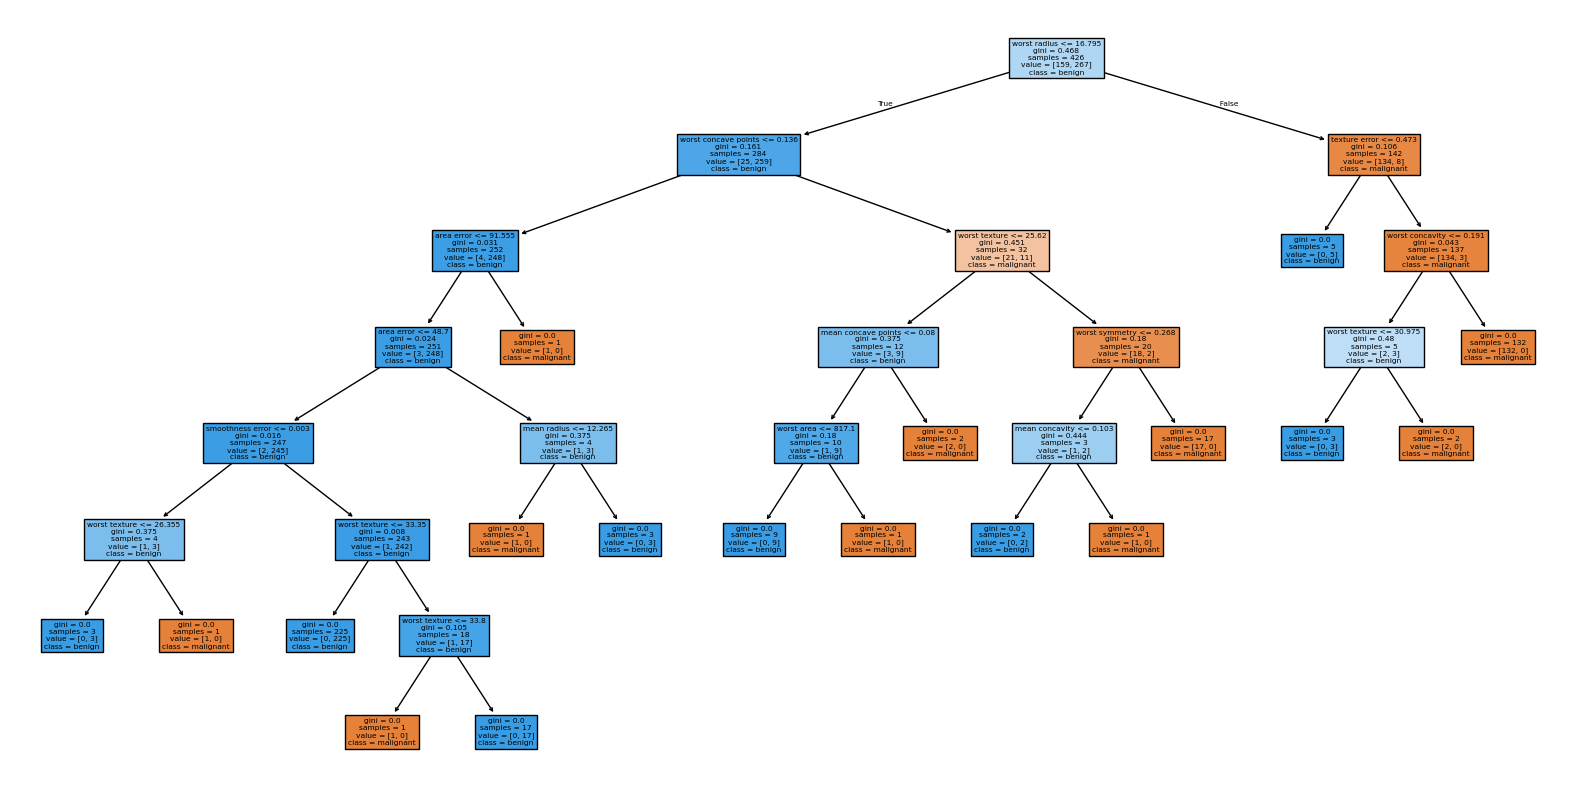

In [24]:
plt.figure(figsize=(20,10))

plot_tree(dt_model,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True)

plt.show()

In [25]:
nb_train_acc = nb_model.score(X_train, y_train)
dt_train_acc = dt_model.score(X_train, y_train)

print("Naive Bayes Training Accuracy:", nb_train_acc)
print("Decision Tree Training Accuracy:", dt_train_acc)

Naive Bayes Training Accuracy: 0.9460093896713615
Decision Tree Training Accuracy: 1.0


In [26]:
nb_test_acc = nb_model.score(X_test, y_test)
dt_test_acc = dt_model.score(X_test, y_test)

print("Naive Bayes Test Accuracy:", nb_test_acc)
print("Decision Tree Test Accuracy:", dt_test_acc)

Naive Bayes Test Accuracy: 0.9370629370629371
Decision Tree Test Accuracy: 0.9230769230769231


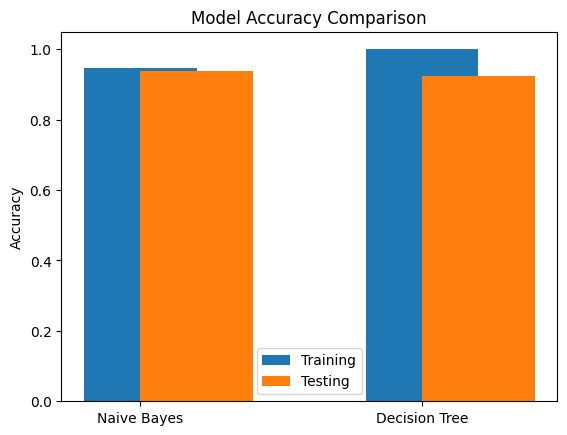

In [27]:
import matplotlib.pyplot as plt

models = ['Naive Bayes','Decision Tree']

train_acc = [nb_train_acc, dt_train_acc]
test_acc = [nb_test_acc, dt_test_acc]

x = range(len(models))

plt.bar(x, train_acc, width=0.4, label='Training', align='center')
plt.bar(x, test_acc, width=0.4, label='Testing', align='edge')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.legend()

plt.show()

In [28]:
from sklearn.metrics import roc_curve, auc

nb_prob = nb_model.predict_proba(X_test)[:,1]
dt_prob = dt_model.predict_proba(X_test)[:,1]

fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

auc_nb = auc(fpr_nb, tpr_nb)
auc_dt = auc(fpr_dt, tpr_dt)

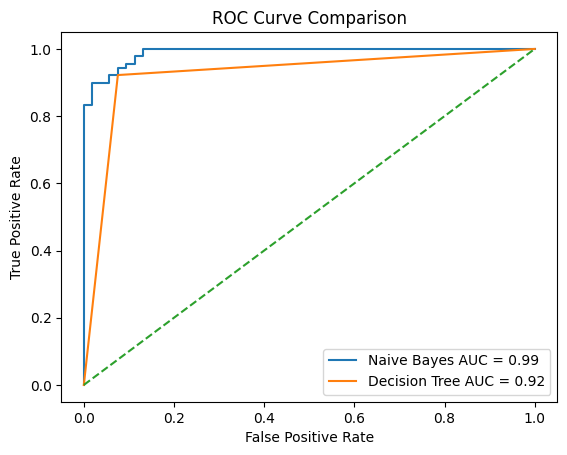

In [29]:
plt.plot(fpr_nb, tpr_nb, label="Naive Bayes AUC = %.2f" % auc_nb)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree AUC = %.2f" % auc_dt)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

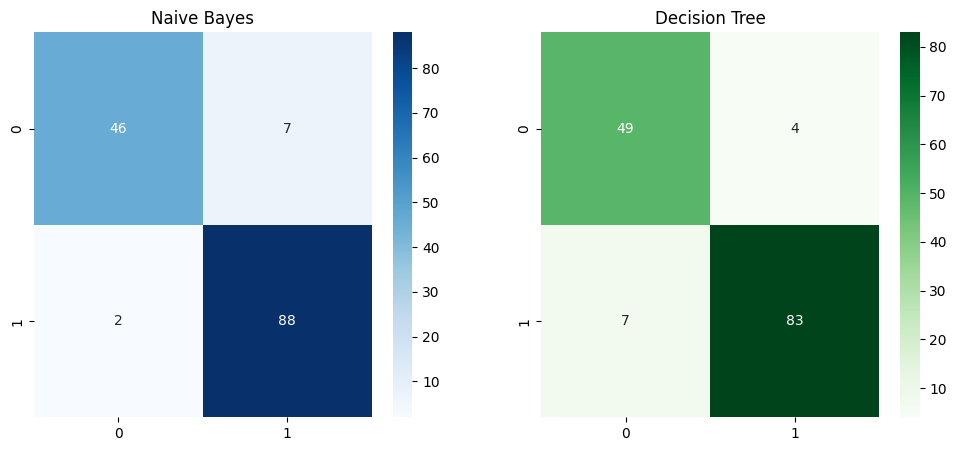

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_nb = confusion_matrix(y_test, y_pred)
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Naive Bayes")

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("Decision Tree")

plt.show()